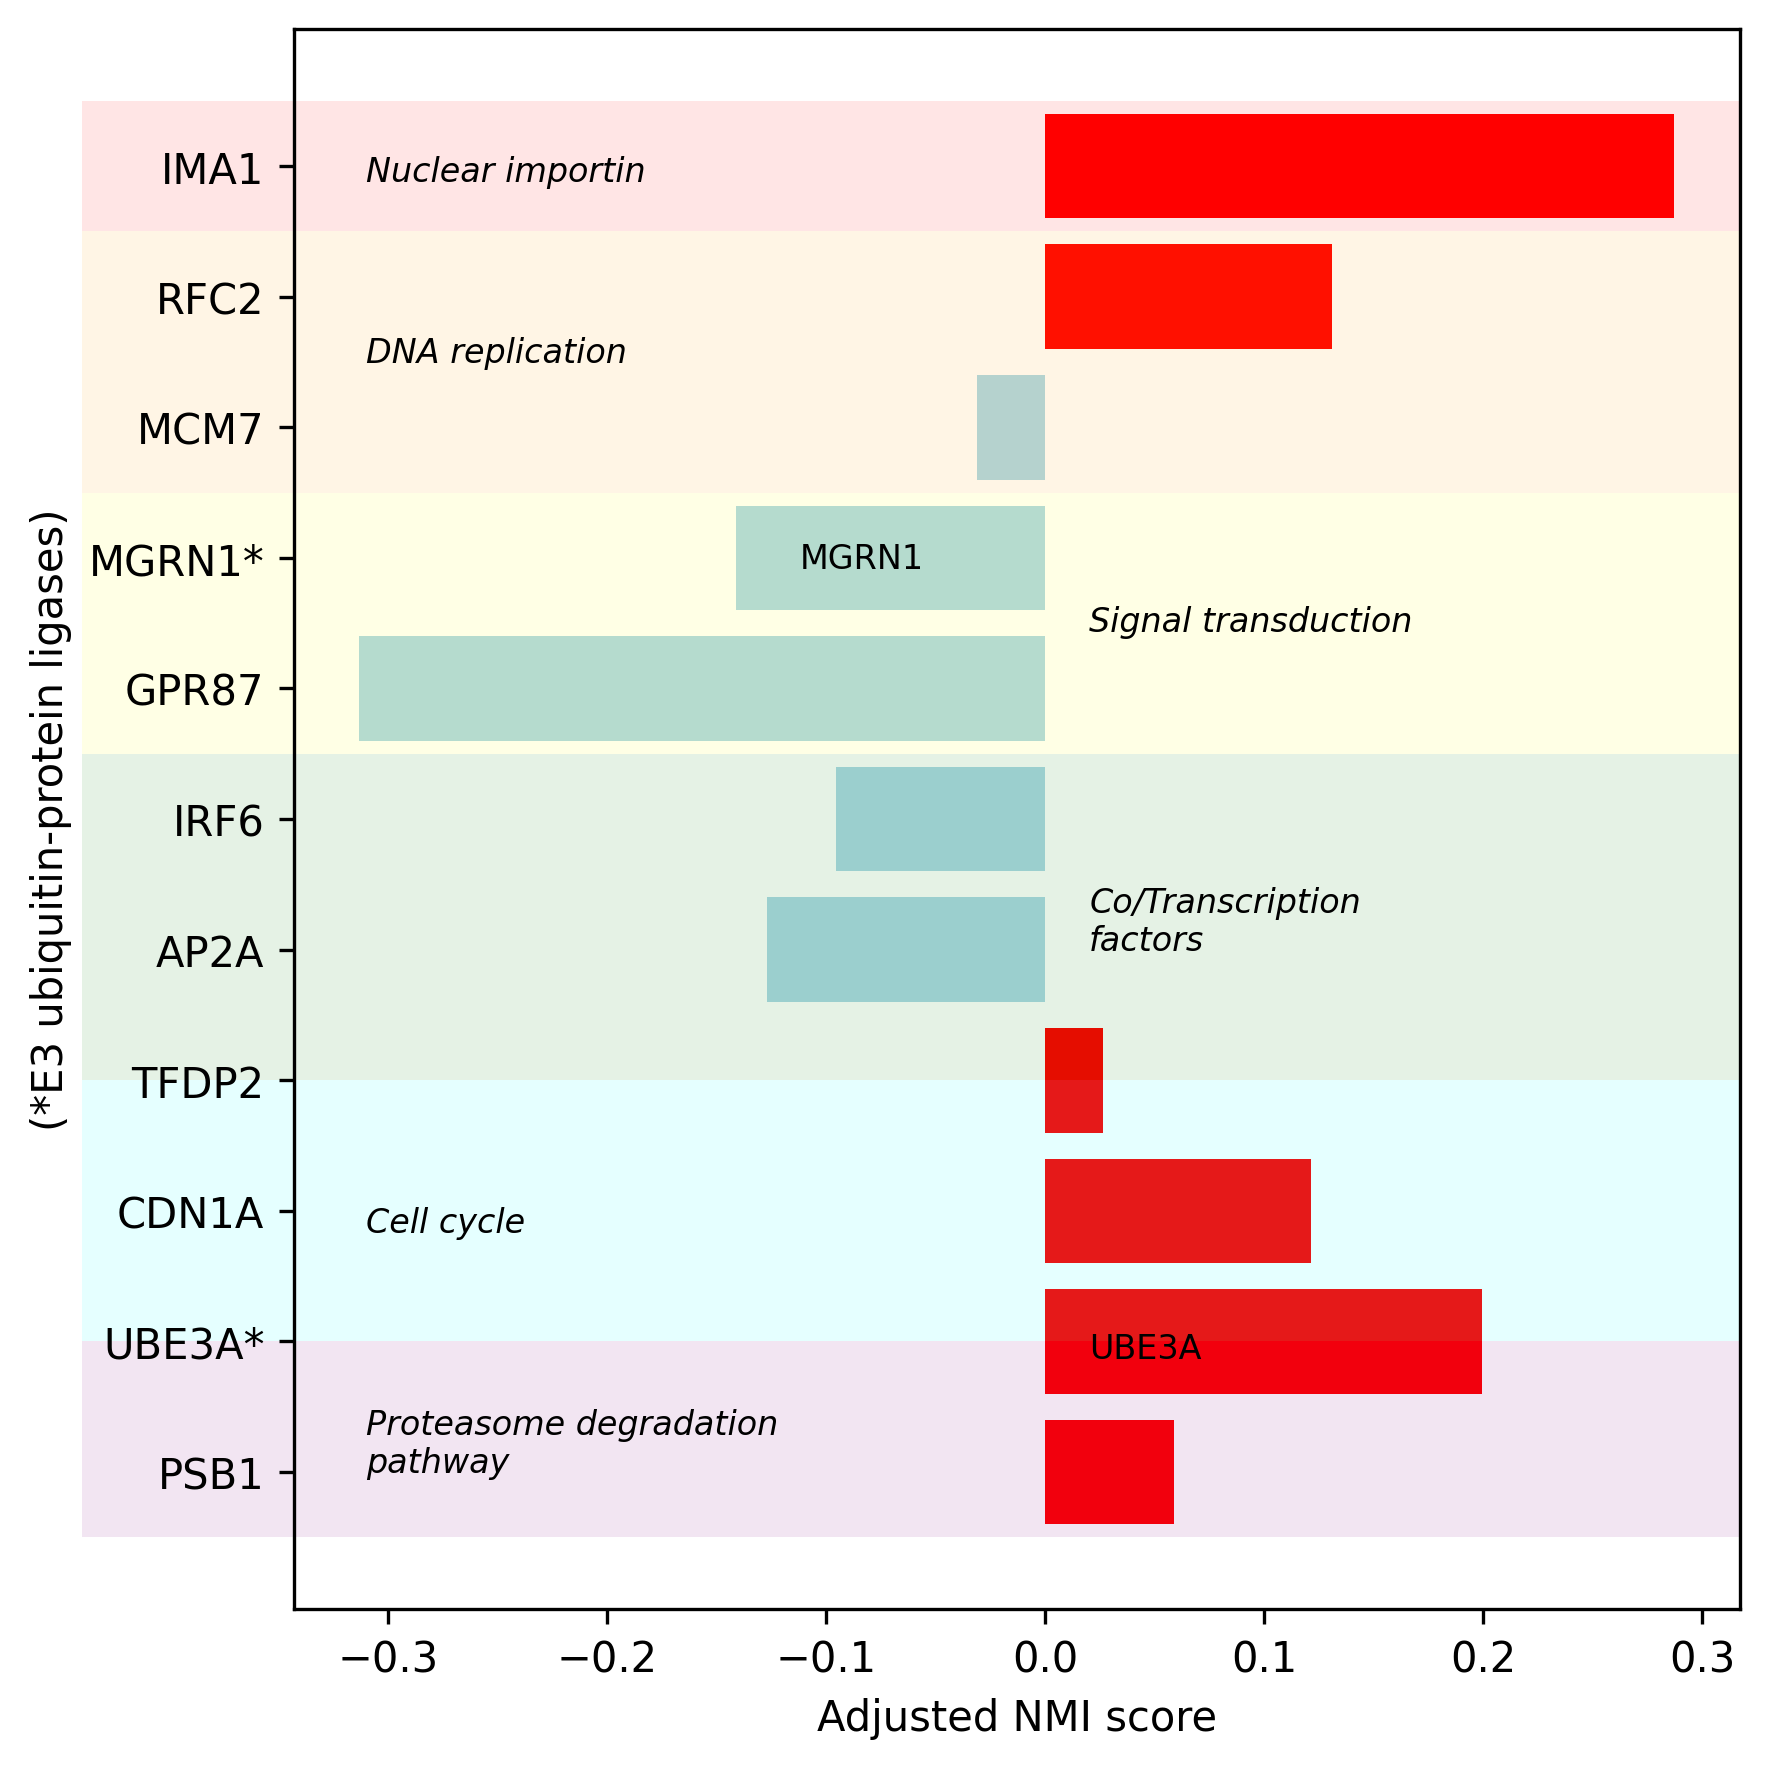

In [25]:
from matplotlib import pyplot as plt

# Data: adjusted NMI per human interactor
adj_score_dic = {
    'O14896': -0.09543611827005628, 'O60291': -0.1413834561724517,
    'P05549': -0.12689011885060159, 'P20618':  0.0589833454536205,
    'P33993': -0.03124497664952592, 'P35250':  0.1309301121007204,
    'P38936':  0.12145912773279521, 'P52292':  0.2873175062148103,
    'Q05086':  0.1995996251548407,  'Q14188':  0.02636177742589371,
    'Q9BY21': -0.31322231262706396
}

# Plot order + display names
id_lst = ['P20618','Q05086','P38936','Q14188','P05549','O14896','Q9BY21','O60291','P33993','P35250','P52292']
id_lst_anno = ['PSB1','UBE3A*','CDN1A','TFDP2','AP2A','IRF6','GPR87','MGRN1*','MCM7','RFC2','IMA1']

fig, ax = plt.subplots(figsize=(6, 6), dpi=300)

# Horizontal bars: red if positive, lightblue otherwise
vals = [adj_score_dic[k] for k in id_lst]
colors = ['red' if v > 0 else 'lightblue' for v in vals]
ax.barh(range(len(id_lst)), vals, align='center', color=colors)

ax.set_yticks(range(len(id_lst)), id_lst_anno)
ax.set_xlabel('Adjusted NMI score')
ax.set_ylabel('(*E3 ubiquitin-protein ligases)')

# Shaded functional bands + annotations (positions kept as your original)
pxlim = ax.get_xlim()
stx = -0.44

ax.text(0.05, 0.105, 'Proteasome degradation\npathway', transform=ax.transAxes,
        va='center', ha='left', fontsize=8, style='italic')
ax.text(0.55, 0.165, 'UBE3A', transform=ax.transAxes, va='center', ha='left', fontsize=8)
ax.text(0.05, 0.245, 'Cell cycle', transform=ax.transAxes, va='center',
        ha='left', fontsize=8, style='italic')
ax.text(0.55, 0.435, 'Co/Transcription\nfactors', transform=ax.transAxes,
        va='center', ha='left', fontsize=8, style='italic')
ax.text(0.55, 0.625, 'Signal transduction', transform=ax.transAxes,
        va='center', ha='left', fontsize=8, style='italic')
ax.text(0.35, 0.665, 'MGRN1', transform=ax.transAxes, va='center', ha='left', fontsize=8)
ax.text(0.05, 0.795, 'DNA replication', transform=ax.transAxes, va='center',
        ha='left', fontsize=8, style='italic')
ax.text(0.05, 0.91, 'Nuclear importin', transform=ax.transAxes, va='center',
        ha='left', fontsize=8, style='italic')

ax.fill_between([stx, pxlim[1]], -0.5,  1.0, color='purple', alpha=0.1, linewidth=0, clip_on=False)
ax.fill_between([stx, pxlim[1]],  1.0,  3.0, color='cyan',   alpha=0.1, linewidth=0, clip_on=False)
ax.fill_between([stx, pxlim[1]],  3.0,  5.5, color='green',  alpha=0.1, linewidth=0, clip_on=False)
ax.fill_between([stx, pxlim[1]],  5.5,  7.5, color='yellow', alpha=0.1, linewidth=0, clip_on=False)
ax.fill_between([stx, pxlim[1]],  7.5,  9.5, color='orange', alpha=0.1, linewidth=0, clip_on=False)
ax.fill_between([stx, pxlim[1]],  9.5, 10.5, color='red',    alpha=0.1, linewidth=0, clip_on=False)

ax.set_xlim(pxlim)
fig.tight_layout()
fig.savefig('Fig6/Figure6B.svg', format='svg', bbox_inches='tight')

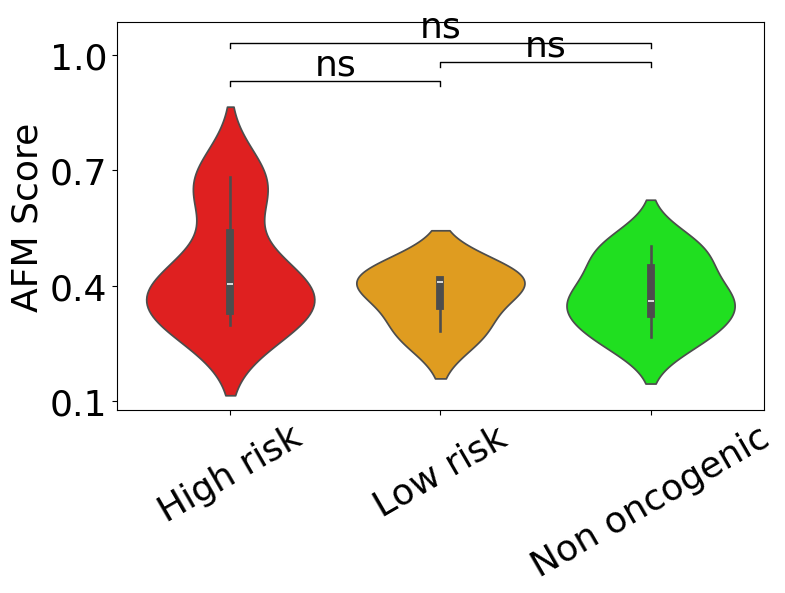

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statannot import add_stat_annotation  # For adding p-value annotations
from scipy.stats import mannwhitneyu  # Or another test as desired
import numpy as np

df = pd.read_csv('Fig6/list_VE6_HPV_IMA1_HUMAN.txt',sep='\t')

# Define custom palette mapping for HPV_anno groups
custom_palette = {
    "High risk": (1,0,0),
    "Low risk": (1,0.65,0),
    "Non oncogenic": (0,1,0)
}

# Create the violin plot grouped by 'HPV_anno'
plt.figure(figsize=(8,6))
order = ['High risk', 'Low risk', 'Non oncogenic']  # adjust if needed
ax = sns.violinplot(
    x='HPV_anno', y='score', hue='HPV_anno',
    data=df, inner='box', order=order, hue_order=order,
    palette=custom_palette, dodge=False, legend=False
)
# Define the pairwise comparisons you want to test.
# In this data, HPV_anno has three groups: 'High risk', 'Low risk', 'Non oncogenic'
box_pairs = [
    ("High risk", "Low risk"),
    ("High risk", "Non oncogenic"),
    ("Low risk", "Non oncogenic")
]

# Add statistical annotation (here using the Mann-Whitney U test)
from scipy.stats import mannwhitneyu

box_pairs = [
    ("High risk", "Low risk"),
    ("Low risk", "Non oncogenic"),
    ("High risk", "Non oncogenic"),
]

def annotate_pvals(ax, data, x, y, pairs, order,
                   pad_frac=0.02, step_frac=0.06, line_frac=0.015, fontsize=26):
    y_min, y_max = ax.get_ylim()
    span = y_max - y_min
    y_cur = y_max + span * pad_frac
    x_idx = {cat: i for i, cat in enumerate(order)}

    for (a, b) in pairs:
        s1 = data.loc[data[x] == a, y].dropna()
        s2 = data.loc[data[x] == b, y].dropna()
        _, p = mannwhitneyu(s1, s2, alternative='two-sided')

        stars = '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else 'ns'
        x1, x2 = x_idx[a], x_idx[b]
        h = span * line_frac

        ax.plot([x1, x1, x2, x2], [y_cur, y_cur + h, y_cur + h, y_cur], c='k', lw=1)
        ax.text((x1 + x2) / 2, y_cur + h, stars, ha='center', va='bottom', fontsize=fontsize)

        y_cur += span * step_frac

    ax.set_ylim(y_min, y_cur + span * pad_frac)

annotate_pvals(ax, df, x='HPV_anno', y='score', pairs=box_pairs, order=order)

# plt.title("Violin Plot of Score by HPV_anno with p-value Annotations")
# plt.xlabel("HPV Annotation")
plt.ylabel("AFM Score", fontsize=26)
plt.xlabel("")
plt.xticks(fontsize=26, rotation=30)
plt.yticks(fontsize=26)
ax.set_yticks(np.arange(0.1, 1.05, 0.3))
plt.tight_layout()
plt.savefig('Fig6/Figure6C.svg',format='svg')

C:\Users\Le Li\AppData\Local\Temp\ipykernel_35272\871657775.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


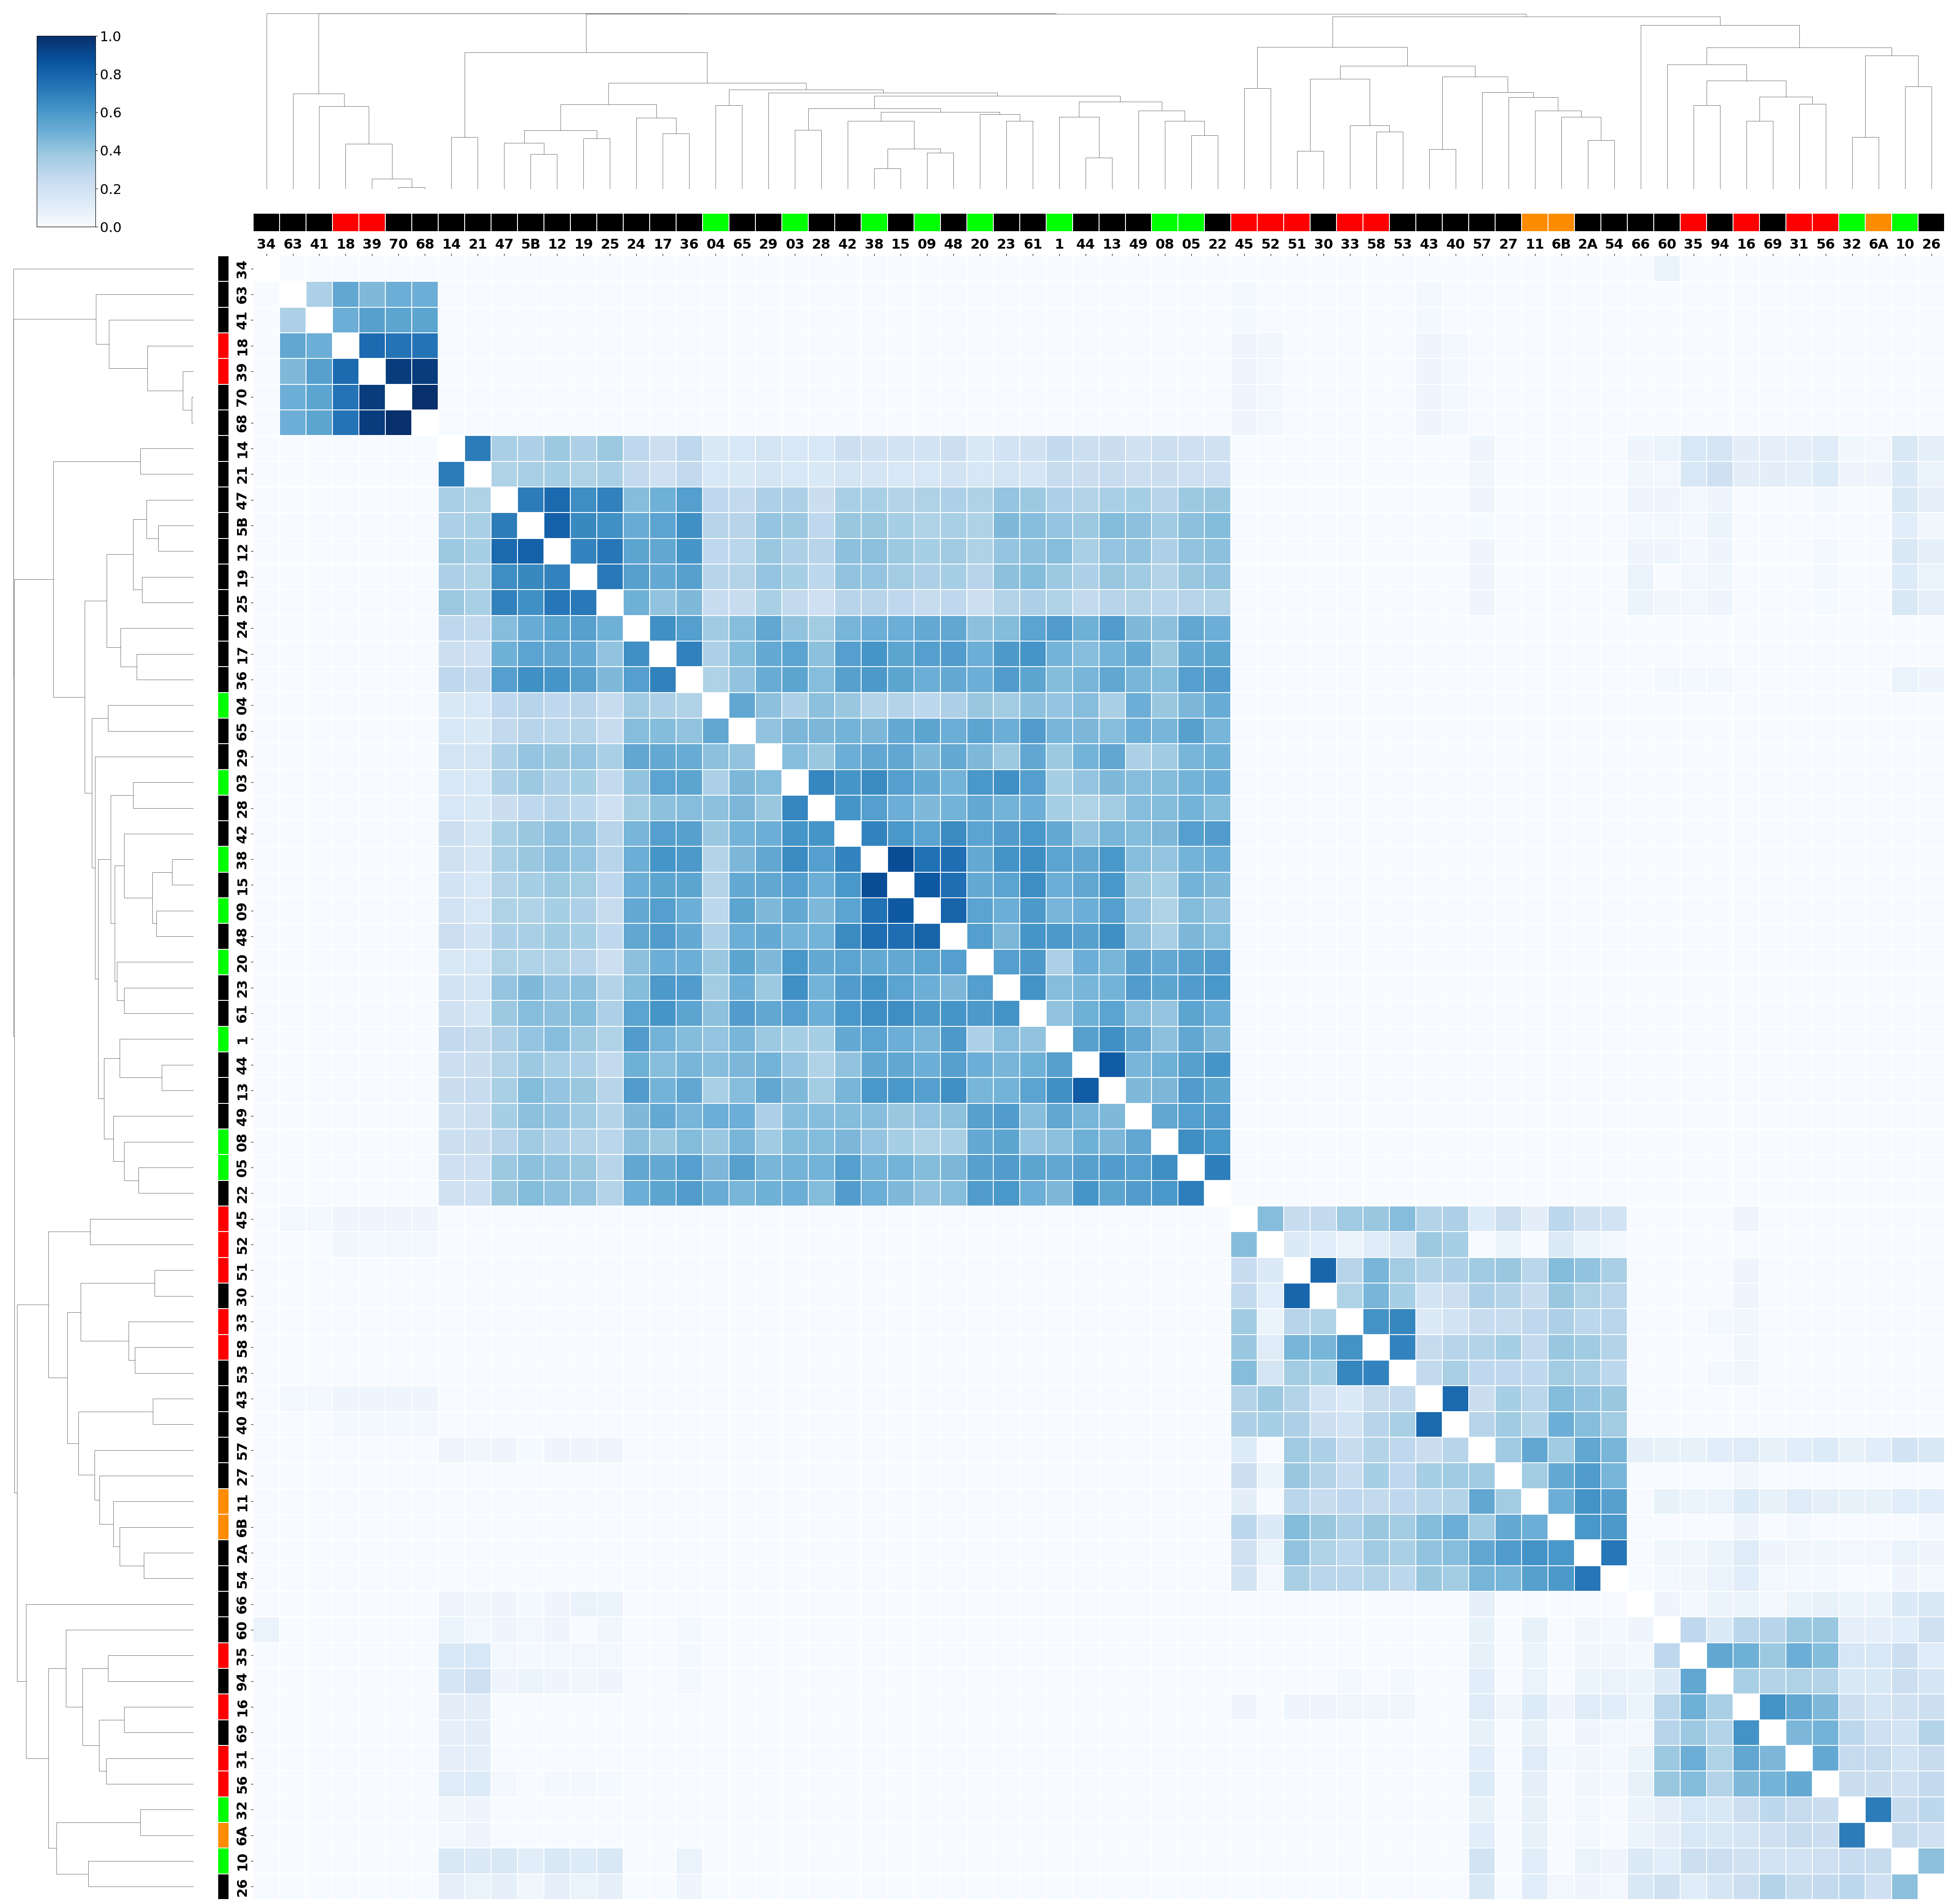

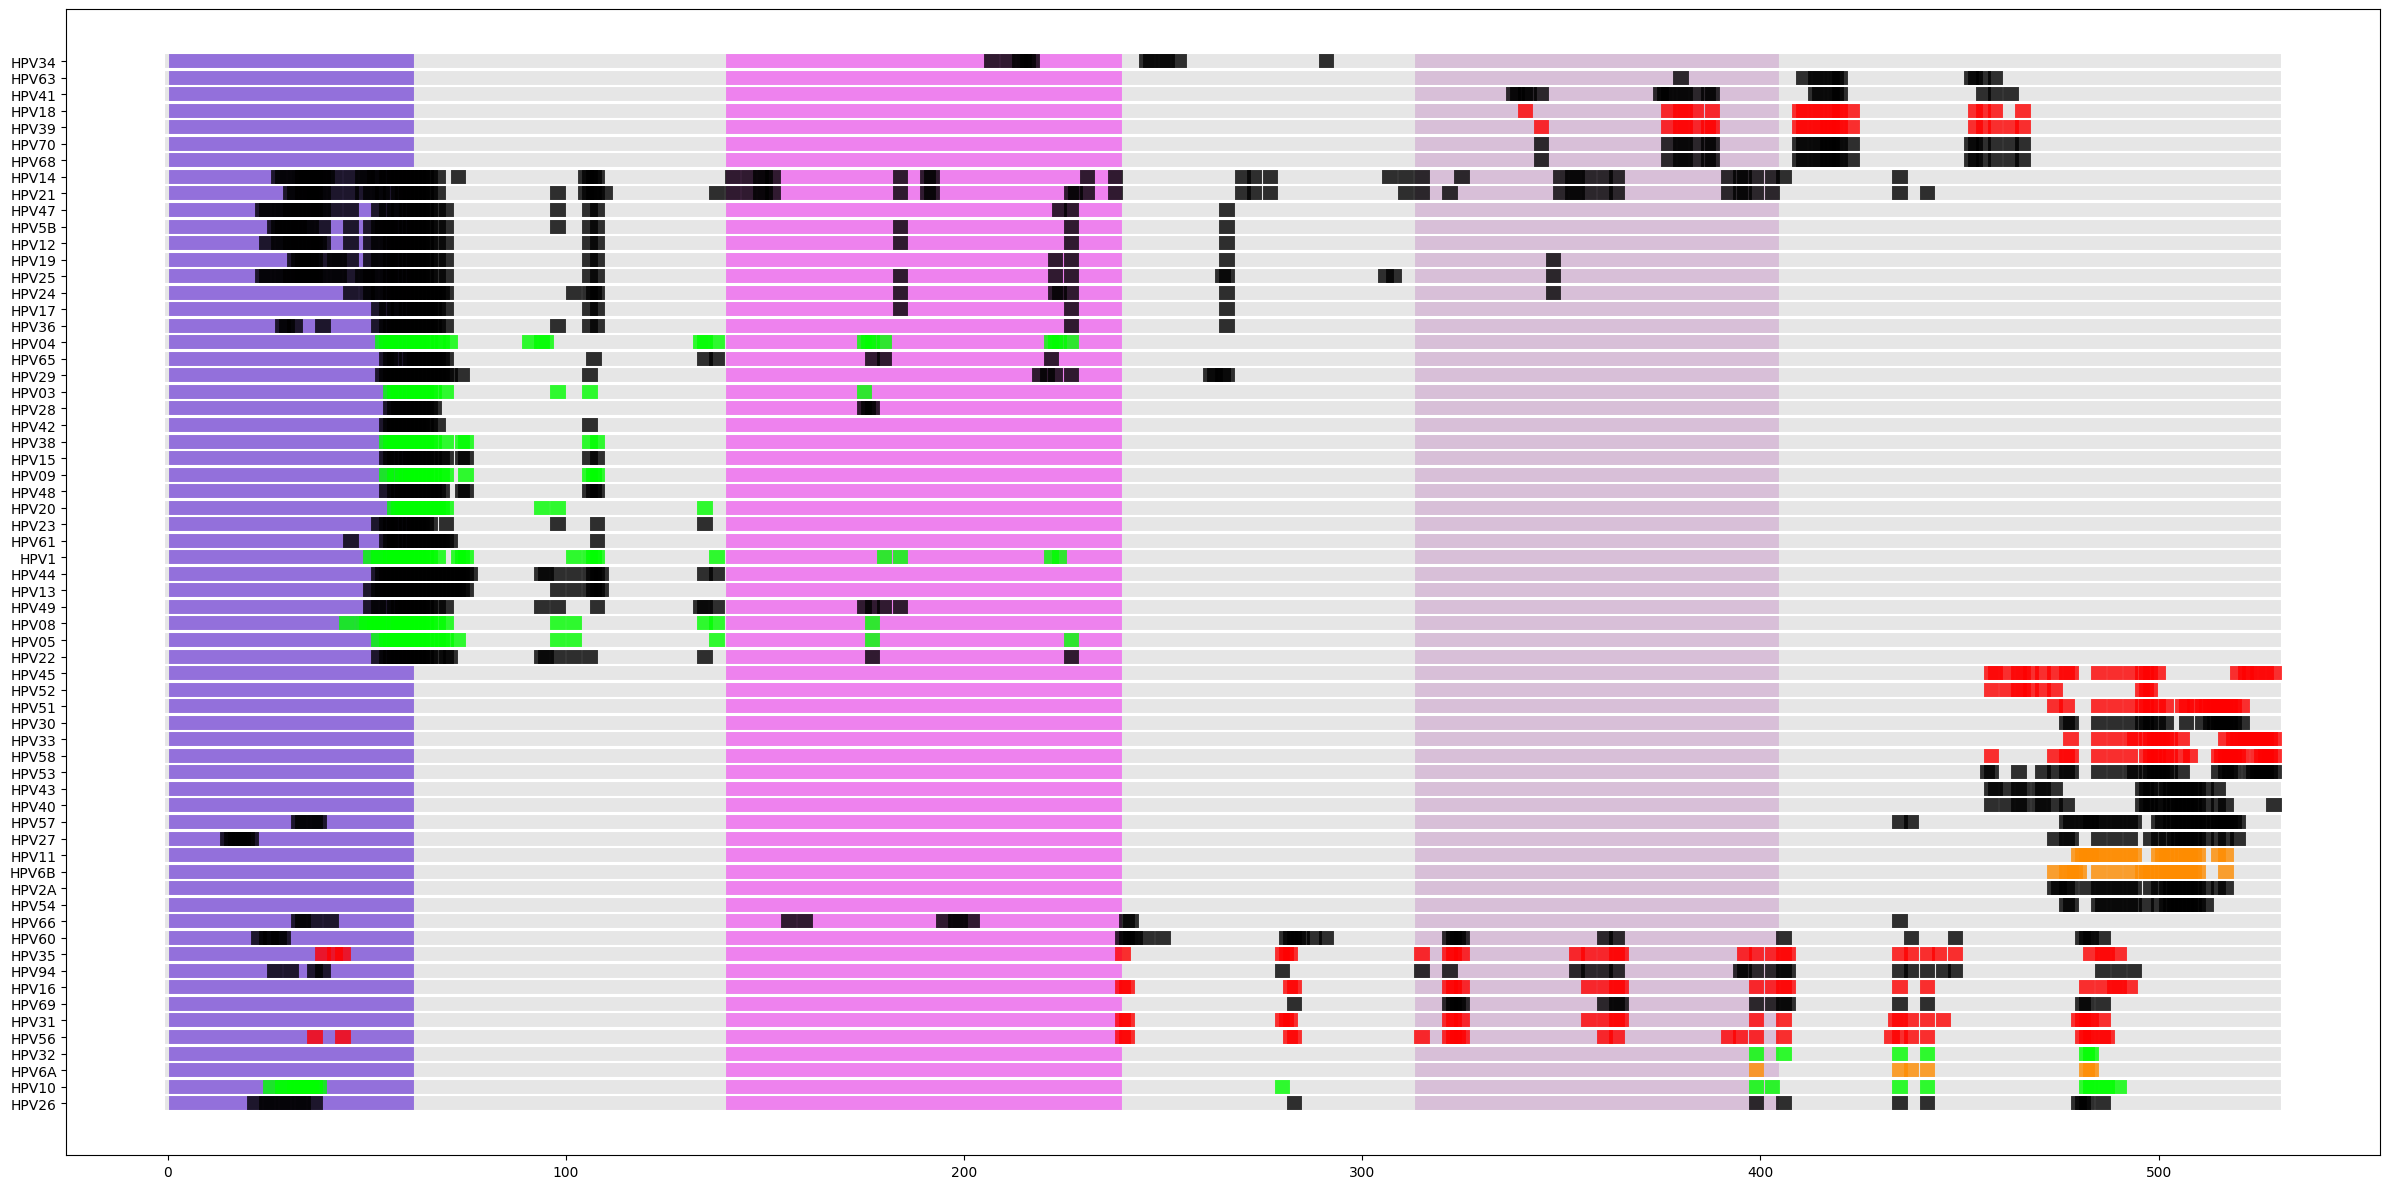

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.spatial as sp
import scipy.cluster.hierarchy as hc
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

# ---------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------
%matplotlib inline
full_list = True  # toggle which input / output names to use

# Input tables
if full_list:
    hpv_lst = pd.read_csv("Fig6/VE6_HPV_IMA1_HUMAN_full.txt", sep="\t")
else:
    hpv_lst = pd.read_csv("Fig6/VE6_HPV_IMA1_HUMAN.txt", sep="\t")

seq_len = 529  # protein length for the right panel tracks

# Which interface definition to visualize
ires_sel = 1
if ires_sel == 1:
    ires_tab = hpv_lst.p2_ires.values  # original interface indices (comma-separated)
    pat = "Origin"
else:
    ires_tab = hpv_lst.Human_ires_plddt50.values  # pLDDT>=50 interface indices
    pat = "pLDDT50"

# ---------------------------------------------------------------------
# Helpers / lookups
# ---------------------------------------------------------------------
lut1 = {
    "High risk": "red",
    "Low risk": "orange",
    "Low risk for other tumors": "y",
    "Non oncogenic": "lime",
    "Unknown": "black",
}
lut2 = {"High risk": "red", "Low risk": "lime", "Unknown": "black", "Medium risk": "darkOrange"}

# Row colors: use the second annotation
row_colors2 = np.vectorize(lut2.get)(hpv_lst.HPV_anno2.values)
row_colors = row_colors2

# Heatmap color map
cmap = matplotlib.cm.Blues
cmap_r = cmap.reversed()

# ---------------------------------------------------------------------
# Build 1 - Jaccard-based similarity matrix
#   similarity = 1 - round(Jaccard_overlap, 2)
#   (where overlap is |A∩B| / |A∪B|)
# ---------------------------------------------------------------------
pro_vec = hpv_lst.vname.values
n = len(pro_vec)
heatm = np.ones((n, n))  # start with ones

for i in range(n - 1):
    heatm[i, i] = 0
    # skip if no interface list for i
    if isinstance(ires_tab[i], float):
        continue
    ires_i = [int(ele) for ele in ires_tab[i].split(",")]

    for j in range(i + 1, n):
        # skip if no interface list for j
        if isinstance(ires_tab[j], float):
            continue
        ires_j = [int(ele) for ele in ires_tab[j].split(",")]

        # Jaccard overlap
        union = len(set(ires_i + ires_j))
        overlap = (len(ires_i + ires_j) - union) / union if union > 0 else 0.0

        sim = 1 - round(overlap, 2)
        heatm[i, j] = sim
        heatm[j, i] = sim

# set the very last diagonal
heatm[n - 1, n - 1] = 0

# Cosmetic scale tweak
heatm = (heatm + 0.01) / 1.01

# ---------------------------------------------------------------------
# Clustering and clustermap
# ---------------------------------------------------------------------
np.fill_diagonal(heatm, 0.0)                 # ensure exact zeros on diagonal
mask = np.eye(heatm.shape[0], dtype=bool)
linkage = hc.linkage(sp.distance.squareform(heatm), method="average")

# Column/row labels: drop the 'HPV' prefix in the heatmap
labels_short = [ele[3:] for ele in pro_vec]

g = sns.clustermap(
    pd.DataFrame(heatm, columns=labels_short, index=labels_short),
    row_colors=row_colors,
    col_colors=row_colors,
    row_linkage=linkage,
    col_linkage=linkage,
    figsize=(0.65 * n + 2, 0.65 * n + 1),
    annot=False,
    dendrogram_ratio=(0.1, 0.1),
    colors_ratio=(0.006, 0.01),
    cmap=cmap_r,
    linewidths=0.005,
    mask=mask,
)

# ---- Manual colorbar ----
cax = g.ax_heatmap.figure.add_axes([0.02, 0.88, 0.03, 0.1])
norm = matplotlib.colors.Normalize(vmin=heatm.min(), vmax=heatm.max())
sm = matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)  # non-reversed on purpose
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax)
cbar.ax.tick_params(labelsize=22)

# Axis tick styling
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize=25)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize=25)
g.ax_heatmap.xaxis.set_ticks_position("top")
g.ax_heatmap.xaxis.set_label_position("top")
g.ax_heatmap.xaxis.tick_top()
g.ax_heatmap.yaxis.set_ticks_position("left")
g.ax_heatmap.yaxis.set_label_position("left")
g.ax_heatmap.yaxis.tick_left()

# Bold, black tick labels
font_prop = FontProperties(weight="bold", size=22)
for lbl in g.ax_heatmap.get_xticklabels():
    lbl.set_fontproperties(font_prop)
    lbl.set_color("black")
for lbl in g.ax_heatmap.get_yticklabels():
    lbl.set_fontproperties(font_prop)
    lbl.set_color("black")

# Hide seaborn's default colorbar
g.cax.set_visible(False)

plt.tight_layout()
if full_list:
    plt.savefig("Fig6/Figure6E_left.png", bbox_inches="tight")
else:
    plt.savefig("Fig6/Figure6D_left.png", bbox_inches="tight")

# ---------------------------------------------------------------------
# Right panel: linear sequence tracks with interface ticks (unchanged)
#   - three colored blocks mark regions [2–60], [142–238], [315–403]
#   - interface residues (from p2_ires) overlaid in risk-category colors
# ---------------------------------------------------------------------
ele_lst = g.data2d.columns.tolist()  # order from clustered heatmap (short labels)

figsize = (24, 12) if full_list else (15, 5)
fig, ax = plt.subplots(figsize=figsize)

# domain blocks
domain_colors = ["mediumpurple", "violet", "thistle"]

cur_y = 1
for short in reversed(ele_lst):
    vir = "HPV" + short

    ires_str = hpv_lst.loc[hpv_lst.vname == vir, "p2_ires"].values[0]
    if isinstance(ires_str, float):
        ires_lst = []
    else:
        ires_lst = [int(x) for x in ires_str.split(",")]

    # gray baseline
    ax.plot(range(1, seq_len + 1), [cur_y] * seq_len, color=[0.9, 0.9, 0.9], linewidth=10)

    # fixed domain segments
    ax.plot(range(2, 61), [cur_y] * 59, color=domain_colors[0], linewidth=10)
    ax.plot(range(142, 239), [cur_y] * 97, color=domain_colors[1], linewidth=10)
    ax.plot(range(315, 404), [cur_y] * 89, color=domain_colors[2], linewidth=10)

    # overlay interface positions in risk color from lut2/HPV_anno2
    risk_color = lut2[hpv_lst.loc[hpv_lst.vname == vir, "HPV_anno2"].values[0]]
    for ii in ires_lst:
        ax.plot([ii - 0.2, ii + 0.2], [cur_y, cur_y], color=risk_color, linewidth=10, alpha=0.8)

    cur_y += 1

# y tick labels follow the clustered order
plt.yticks(range(1, hpv_lst.shape[0] + 1), ["HPV" + s for s in reversed(ele_lst)])

plt.tight_layout()
if full_list:
    plt.savefig("Fig6/Figure6E_right.png", bbox_inches="tight")
else:
    plt.savefig("Fig6/Figure6D_right.png", bbox_inches="tight")
